# Lab 2

Lab 1 built a network with `nn.Sequential` and trained it by calling `loss.backward()` -
PyTorch's autograd worked out every gradient for us, as a black box. This lab is an
optional follow-up for anyone curious what that black box was actually doing: first we
hand-build a small network to see *why* depth gives a network more representational
power, then we implement backpropagation ourselves, with plain tensor arithmetic and no
autograd at all.

## Setup

These labs are designed to run on [Google Colab](https://colab.research.google.com/) -
no local Python install needed. Open this notebook via Colab's GitHub loader
(`colab.research.google.com/github/KarikS/lecture_advanced_ai_ml/blob/main/<path-to-this-notebook>`)
or File > Open notebook > GitHub tab, repo `KarikS/lecture_advanced_ai_ml`, then run
the cell below once per session. It clones this repository so the notebook has the
rest of the course code available - this particular lab needs no external data files,
but the setup step is kept identical across every lab. Running the notebook locally
instead (e.g. via the `exercises/python/` venv described in that folder's README) works
unchanged - the cell below is a no-op there.

In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import os
    if not os.path.exists('lecture_advanced_ai_ml'):
        !git clone https://github.com/KarikS/lecture_advanced_ai_ml.git

## Imports

In [2]:
from typing import List, Optional, Tuple

import torch
from torch import Tensor

import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats('png', 'pdf')

## Exercise 1

### Why do we need two hidden layers?

Consider a neural network with a single hidden layer of threshold units
($\tau(x)=\mathbf{1}[x>0]$) and one unactivated output neuron. No matter how many
hidden units it has, such a network **cannot exactly separate** a "bow tie" region made
of two disjoint triangles (plotted below) from everything around it - a short proof by
contradiction is given in Blum, Edward K., and Leong Kwan Li. 1991. "Approximation
Theory and Feedforward Networks." *Neural Networks* (4): 511-15.
https://doi.org/10.1016/0893-6080(91)90047-9. We won't reproduce the proof here (see
the reference if you're curious); instead we'll build the fix directly: with **two**
hidden layers, we can carve out this exact shape by composing linear classifiers, one
decision boundary at a time.

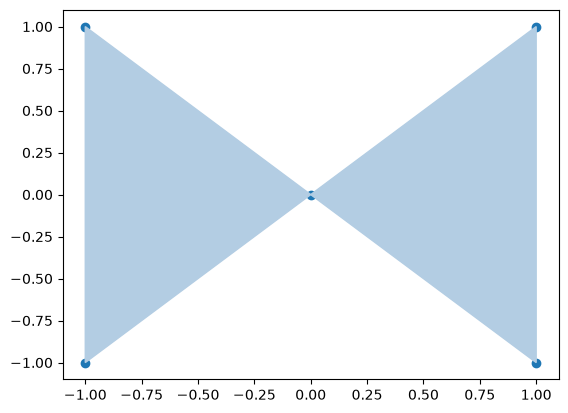

In [3]:
dots = torch.tensor([[-1, 1], [-1, -1], [0, 0], [1, 1], [1, -1]])
plt.figure()
plt.scatter(dots[:, 0], dots[:, 1])
t1 = plt.Polygon([[-1, 1], [-1, -1], [0, 0]], color='#b3cde3')
plt.gca().add_patch(t1)

t2 = plt.Polygon(dots[2:5, :], color='#b3cde3')
plt.gca().add_patch(t2)
plt.show()

Let us create a dataset containing points on a grid to test the network:

In [4]:
# Build a grid of equally-spaced points, plus a column for the bias
grid_range = torch.linspace(-2, 2, 50)
grid_x, grid_y = torch.meshgrid(grid_range, grid_range, indexing='ij')
data = torch.stack([torch.ones(50**2), grid_x.flatten(), grid_y.flatten()]).T

print(data.shape)
print(data[:10])

torch.Size([2500, 3])
tensor([[ 1.0000, -2.0000, -2.0000],
        [ 1.0000, -2.0000, -1.9184],
        [ 1.0000, -2.0000, -1.8367],
        [ 1.0000, -2.0000, -1.7551],
        [ 1.0000, -2.0000, -1.6735],
        [ 1.0000, -2.0000, -1.5918],
        [ 1.0000, -2.0000, -1.5102],
        [ 1.0000, -2.0000, -1.4286],
        [ 1.0000, -2.0000, -1.3469],
        [ 1.0000, -2.0000, -1.2653]])


### First hidden layer
The first hidden layer contains four neurons, each of which corresponds to a
line in the plot below.

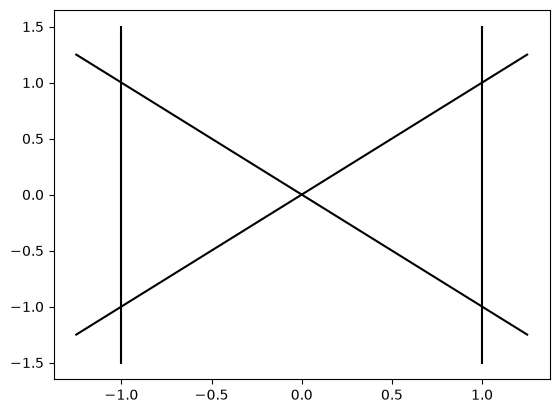

In [5]:
def plot_bowtie() -> None:
    plt.plot((1.25, -1.25), (1.25, -1.25), 'k')
    plt.plot((1.25, -1.25), (-1.25, 1.25), 'k')
    plt.plot((-1, -1), (-1.5, 1.5), 'k')
    plt.plot((1, 1), (-1.5, 1.5), 'k')

plot_bowtie()
plt.show()

The following function visualizes the decision boundary of a neuron with sigmoid
activation, $y=\sigma(a+bx_1+cx_2)$. You can use it to help you find the right
values for the weights.

In [6]:

def plot_decision_boundary(grid_x: Tensor, grid_y, pred: Tensor) -> None:
    """Plot the estimated decision boundary for a 2D grid with predictions."""
    plot_bowtie()
    plt.contourf(grid_x, grid_y, pred.view(grid_x.shape))
    plt.show()

def activation(x: Tensor) -> Tensor:
# TODO apply the threshold activation to x.

def plot_decision_boundary_first_hidden(a: int, b: int, c: int) -> None:
    """Take 3 weights for one input neuron and plot resulting decision boundary."""
    neuron_output = (
# TODO compute the output of the neuron with input weights given by a, b and c
# on each point of the grid.
    )
    plot_decision_boundary(grid_x, grid_y, neuron_output)

plot_decision_boundary_first_hidden(-1, -3, 1)

For convenience, we group the parameters of the four neurons into a matrix with three
rows and five columns (one is for the bias), so that their output can be computed in a
single matrix multiplication. Each column contains the weights of a different neuron.
The first column contains a "fake" hidden neuron for the bias, whose value is always
one. Note that the first row of the weight matrix is connected to the bias of the
previous layer.

In [7]:

weights_1 = torch.tensor([
    [1, 0, 0],   # bias neuron connected to the bias of the inputs
# TODO find the coefficients for the first neuron.
# TODO find the coefficients for the second neuron.
# TODO find the coefficients for the third neuron.
# TODO find the coefficients for the fourth neuron.
], dtype=torch.float).T
# Note: The weight matrix is transposed in the end. (5 x 3 --> 3 x 5)
# This gives more readability when entering your weights manually.

print(weights_1.shape)

Let us plot the predictions of the four neurons:

In [8]:
plot_decision_boundary_first_hidden(*weights_1[:, 1])

In [9]:
plot_decision_boundary_first_hidden(*weights_1[:, 2])

In [10]:
plot_decision_boundary_first_hidden(*weights_1[:, 3])

In [11]:
plot_decision_boundary_first_hidden(*weights_1[:, 4])

And this is the first hidden layer of the network. Let us compute its predictions for
each point of the grid:

In [12]:

hidden_1 = (
# TODO compute the output of the first hidden layer using a matrix multiplication.
)

# Make sure that the number of rows is not changed,
print(len(hidden_1) == len(data))

# that there are five columns,
print(hidden_1.shape[1] == 5)

# and that the values are between zero and one
print(float(torch.min(hidden_1)), float(torch.max(hidden_1)))

### Second hidden layer
The second hidden layer is composed of two neurons, each activating for inputs inside
one of the two triangles that make up our figure. These two neurons are connected to the
four neurons of the previous layer, thus each of them has five parameters.

Let us first create a new function to visualize the decision boundary of these
neurons in the second hidden layer.

In [13]:
def plot_decision_boundary_second_hidden(a: int, b: int, c: int, d: int, e: int) -> None:
    """Take 5 weights for one hidden neuron and plot resulting decision boundary."""
    neuron_output = (
# TODO compute the output of the neuron.
# (The input is the result from the first layer)
    )
    plot_decision_boundary(grid_x, grid_y, neuron_output)

plot_decision_boundary_second_hidden(-2, 3, -1, -3, 1)

Now, as before, find the coefficients for the two neurons and put them into a matrix
with five rows and two columns. You can use the previous function to help you find
these weights.

**Hint:** You can think of these neurons as performing a logical AND operation on the
outputs of the neurons of the previous layer. All points inside each triangle must be
on the same side of three decision boundaries.

In [14]:

weights_2 = torch.tensor([
    [1, 0, 0, 0, 0],   # bias neuron connected to the bias of the inputs
# TODO find the coefficients for the first neuron.
# TODO find the coefficients for the second neuron.
], dtype=torch.float).T
# Note: The weight matrix is transposed in the end. (3 x 5 --> 5 x 3)
# This gives more readability when entering your weights manually.

# TODO print the shape of the weight matrix to check that it is correct.

In [15]:
plot_decision_boundary_second_hidden(*weights_2[:, 1])

In [16]:
plot_decision_boundary_second_hidden(*weights_2[:, 2])

In [17]:

hidden_2 = (
# TODO compute the output of the second hidden layer.
)

# Make sure that the number of rows is not changed,
print(len(hidden_2) == len(data))

# that there are three columns (the bias-passthrough plus the two real neurons),
print(hidden_2.shape[1] == 3)

# and that the values are between zero and one
print(float(torch.min(hidden_2)), float(torch.max(hidden_2)))

### Output layer
Finally, we can seek the parameters for the output neuron.
It should activate when an input is inside either one of the two triangles.

**Hint:** You can think of the output neuron as performing a logical OR operation on
the outputs of the second hidden layer.

Let us again modify the visualization function to show the decision of the network:

In [18]:
def plot_decision_boundary_output(a: int, b: int, c: int) -> None:
    """Take 3 weights for one output neuron and plot resulting decision boundary."""
    neuron_output = (
# TODO compute the output of the output neuron.
# (The input is the result from the second layer)
    )
    plot_decision_boundary(grid_x, grid_y, neuron_output)

Now fill in the parameters:

In [19]:

weights_3 = torch.tensor([
# TODO find the coefficients for the output neuron.
], dtype=torch.float)

print(weights_3.shape)

The output of the neural network is:

In [20]:
plot_decision_boundary_output(*weights_3)

Let us recap how the output is computed:

In [21]:
hidden_1 = activation(data @ weights_1)
hidden_2 = activation(hidden_1 @ weights_2)
output = hidden_2 @ weights_3

This is, in essence, the *forward pass*. If you did everything correctly, you should
see below the bow-tie shape we set out to reproduce - something a single hidden layer
provably cannot do, but two hidden layers can, just by composing simpler linear
classifiers.

In [22]:
plot_decision_boundary(grid_x, grid_y, output)

## Exercise 2

Lab 1's training loop called `loss.backward()` and let PyTorch's autograd work out
every gradient for us. Here we implement that machinery ourselves, using plain tensor
arithmetic - no autograd, no `nn.Module`.

For a network with $L$ layers, write $\mathbf{z}^{(\ell)}_{out}=\sigma^{(\ell)}(\mathbf{z}^{(\ell)}_{in})$
for the output of layer $\ell$, and $\delta^{(\ell)}=\partial\mathcal{L}/\partial\mathbf{z}^{(\ell)}_{in}$
for the gradient of the loss with respect to that layer's pre-activation input. The
backpropagation algorithm computes, layer by layer from the output backward:

$$
\delta^{(L)} = \frac{\partial\mathcal{L}}{\partial\mathbf{z}^{(L)}_{out}}\odot{\sigma^\prime}^{(L)}(\mathbf{z}^{(L)}_{in})
$$

$$
\frac{\partial\mathcal{L}}{\partial\mathbf{W}^{(\ell)}}={\mathbf{z}^{(\ell-1)}_{out}}^T\delta^{(\ell)}
\qquad\qquad
\frac{\partial\mathcal{L}}{\partial\mathbf{b}^{(\ell)}}=\textstyle\sum_i\delta^{(\ell)}_i
$$

$$
\delta^{(\ell-1)} = \left(\delta^{(\ell)}{\mathbf{W}^{(\ell)}}^T\right)\odot{\sigma^\prime}^{(\ell-1)}(\mathbf{z}^{(\ell-1)}_{in})
$$

These equations are given - you don't need to derive them (that derivation is Session
3's "Backpropagation Optimizer" material). Your job below is to turn them into code.

**NOTE**: We use PyTorch only as a computation engine (tensors and matrix ops). To
showcase how backpropagation works under the hood, we do not use autograd, `nn.Module`,
or any other PyTorch structure that would compute gradients for us - just basic Python
objects, following the forward/backward naming convention PyTorch itself uses.

In [23]:
class Linear:
    def __init__(self, in_features: int, out_features: int):
        self.weight = self._init_glorot(in_features, out_features)
        self.bias = torch.zeros(out_features)

        self.weight_grad: Optional[Tensor] = None
        self.bias_grad: Optional[Tensor] = None

    @staticmethod
    def _init_glorot(in_features: int, out_features: int) -> Tensor:
        """Init a weight matrix with glorot initialization."""
        b = torch.sqrt(torch.tensor([6. / (in_features + out_features)]))
        return (2 * b) * torch.rand(in_features, out_features) - b

    def forward(self, x: Tensor) -> Tensor:
        return x @ self.weight + self.bias

class Sigmoid:
    def __init__(self):
        self.func = lambda x: 1 / (1 + torch.exp(-x))

    def forward(self, x: Tensor) -> Tensor:
        return self.func(x)

    def get_gradient(self, x: Tensor) -> Tensor:
        return self.func(x) * (1 - self.func(x))

class TanH:
    @staticmethod
    def forward(x: Tensor) -> Tensor:
        return torch.tanh(x)

    @staticmethod
    def get_gradient(x: Tensor) -> Tensor:
        return 1 - torch.tanh(x)**2

class MSELoss:
    @staticmethod
    def forward(y_true: Tensor, y_pred: Tensor) -> Tensor:
        return torch.mean((y_true - y_pred)**2)

    @staticmethod
    def get_gradient(y_true: Tensor, y_pred: Tensor) -> Tensor:
        return 2 * (y_pred - y_true) / len(y_true)


# Now we bring everything together and create our neural network.
class NeuralLayer:
    def __init__(self, in_features: int, out_features: int, activation: str):
        self.linear = Linear(in_features, out_features)

        if activation == 'sigmoid':
            self.act = Sigmoid()
        elif activation == 'tanh':
            self.act = TanH()
        else:
            raise ValueError('{} activation is unknown'.format(activation))

        # We save the last computation as we'll need it for the backward pass.
        self.last_input: Optional[Tensor] = None
        self.last_zin: Optional[Tensor] = None
        self.last_zout: Optional[Tensor] = None

    def forward(self, x: Tensor) -> Tensor:
        self.last_input = x
        self.last_zin = self.linear.forward(x)
        self.last_zout = self.act.forward(self.last_zin)
        return self.last_zout

    def get_weight(self) -> Tensor:
        """Get the weight matrix in the linear layer."""
        return self.linear.weight

    def get_bias(self) -> Tensor:
        """Get the bias vector in the linear layer."""
        return self.linear.bias

    def set_weight_gradient(self, grad: Tensor) -> None:
        """Set a tensor as gradient for the weight in the linear layer."""
        self.linear.weight_grad = grad

    def set_bias_gradient(self, grad: Tensor) -> None:
        """Set a tensor as gradient for the bias in the linear layer."""
        self.linear.bias_grad = grad


class NeuralNetwork:
    def __init__(self, input_size: int, output_size: int, hidden_sizes: List[int]):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_sizes = hidden_sizes

        self.layers: List[NeuralLayer] = []
        layer_sizes = [self.input_size] + self.hidden_sizes
        for i in range(1, len(layer_sizes)):
            self.layers.append(NeuralLayer(layer_sizes[i - 1], layer_sizes[i], 'tanh'))
        self.layers.append(NeuralLayer(hidden_sizes[-1], self.output_size, 'sigmoid'))

        self.loss = MSELoss()

    def forward(self, x: Tensor) -> Tensor:
# TODO perform the forward pass and return the predictions.

    def get_loss(self, x: Tensor, y: Tensor) -> Tensor:
        """Compute the loss for a dataset and given labels."""
# TODO: use the loss function and the forward method to compute the loss.

    def backward(self, x: Tensor, y: Tensor) -> None:
        """Compute all gradients via backpropagation, using the equations above."""
        # Perform forward pass. The z's are automatically saved by NeuralLayer.
        y_pred = self.forward(x)

# TODO: compute the gradients using the equations given above.
# Hint: rely on the objects and structures defined above (especially
# NeuralLayer!). Remember that z_in and z_out are saved in the `linear`
# object of NeuralLayer.

        # Check if gradients have the right size.
        for i, layer in enumerate(self.layers):
            if layer.linear.weight_grad.shape != layer.linear.weight.shape \
                or layer.linear.bias_grad.shape != layer.linear.bias.shape:
                raise ValueError('Gradients in layer with index {} have a wrong shape.'
                                 .format(i))

    def apply_gradients(self, learning_rate: float) -> None:
        """Update weights with the computed gradients (plain gradient descent)."""
# TODO: apply the gradients stashed in NeuralLayer/Linear via gradient descent.

After defining our network, we can create it and check that the passes run without
errors on our small five-point dataset:

In [24]:

x = torch.tensor([
    [0, 0],
    [1, 0],
    [0, -1],
    [-1, 0],
    [0, 1]
], dtype=torch.float)
y = torch.tensor([1, 0, 0, 0, 0])

network = NeuralNetwork(
    input_size=2,
    hidden_sizes=[5, 3],
    output_size=1
)

print(network.forward(x))
network.backward(x, y)

We can inspect the decision boundary, as in Exercise 1, for the randomly initialized
network:

In [25]:

def plot_network_decision_boundary(x: Tensor, y: Tensor, net: NeuralNetwork) -> None:
    grid_range = torch.linspace(-2, 2, 50)
    grid_x, grid_y = torch.meshgrid(grid_range, grid_range, indexing='ij')
    grid_data = torch.stack([grid_x.flatten(), grid_y.flatten()]).T

    predictions = net.forward(grid_data)

    plt.contourf(grid_x, grid_y, predictions.view(grid_x.shape))
    plt.scatter(x[0, 0], x[0, 1], c='red', label='1')
    plt.scatter(x[1:, 0], x[1:, 1], c='black', label='0')
    plt.legend()
    plt.show()

plot_network_decision_boundary(x, y, network)

We can now finally train our network - using only the `backward` and `apply_gradients`
methods you just implemented, no autograd anywhere:

In [26]:

def train(
        x: Tensor,
        y: Tensor,
        net: NeuralNetwork,
        epochs: int,
        lr: float,
        verbose: int = 1,
) -> Tuple[NeuralNetwork, Tensor]:
    """
    Train a neural network with full-batch gradient descent.
    :param x: Training dataset.
    :param y: Training labels.
    :param net: Neural network to train.
    :param epochs: Number of training epochs.
    :param lr: Learning rate for gradient descent.
    :param verbose: Print the loss every this many epochs (0 to disable).
    :return: Trained network and losses over the course of training.
    """
# TODO iterate over the dataset for the given number of epochs and update the
# weights at each epoch. Use all the data to compute the gradients, and track
# the loss so we can see whether training is going well.
    return net, torch.stack(losses)

network, losses = train(x, y, network, 2500, 0.25, verbose=500)

By plotting the loss after each parameter update, we can check that the network
converged:

In [27]:
plt.plot(losses)
plt.show()

And the decision boundary of the trained network is:

In [28]:
plot_network_decision_boundary(x, y, network)

Try training a few randomly initialized networks and vary the depth and hidden sizes
to see different decision boundaries. Try modifying the learning rate and see how it
affects convergence speed. Finally, try different weight initializations and see how
trainability is affected.

### Conclusion

Here's what you should take away from this lab:

 - A single hidden layer of threshold units has provably limited representational
power; stacking hidden layers lets a network compose simple linear decision
boundaries into much more complex ones.
 - Backpropagation is nothing but the chain rule, applied systematically from the
output layer backward, one layer at a time. `loss.backward()` in Lab 1 was doing
exactly the computation you just wrote by hand, just automatically and for arbitrary
computation graphs.
 - Now that you've built it yourself, `nn.Module` and autograd in Lab 1 should feel
less like magic and more like a (very convenient) shortcut.